# 09 文本数据挖掘与非结构化数据分析

本 Notebook 在之前表格数据分析的基础上，进一步利用 Steam 数据中的**非结构化文本字段**进行分析。课程将大数据类型分为六类：表格数据、序列数据、图数据、时空数据、非结构化文本数据和多模态数据。前面的 Notebook 已经充分覆盖了表格数据处理，也涉及了发行年份的时序趋势对比和标签共现的图数据视角。本 Notebook 的目的，是补上**非结构化文本数据处理**这一维度。

具体来说，本节使用以下文本字段：
- `short_description`：游戏简短描述（英文），覆盖 89,498 款游戏
- `about_the_game`：游戏详细描述（英文），覆盖 89,398 款游戏
- `tags_list` / `genres_list`：Steam 标签与类型（对市场词汇的文本分析）

主要分析方向：
1. **词云与高频词分析**：对标签体系和游戏描述文本进行词频统计与可视化
2. **TF-IDF 关键词提取**：对比不同评论量级游戏在描述文本上的关键词差异
3. **文本长度与热度关系**：描述长度、标签丰富度与玩家关注度的关联
4. **图数据视角衔接**：将标签共现网络作为图数据分析的切入点

所有分析均为描述性分析，不涉及因果推断或预测建模。

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud, STOPWORDS
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from nltk.corpus import stopwords as nltk_stopwords

warnings.filterwarnings("ignore")

# ── Project root detection ──
current_dir = Path.cwd().resolve()
fallback_root = Path("/Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights")
root_candidates = [fallback_root, current_dir, *current_dir.parents]
PROJECT_ROOT = next(
    (
        candidate for candidate in root_candidates
        if (candidate / "README.md").exists() and (candidate / "data" / "processed").exists()
    ),
    current_dir,
)
print("Project root:", PROJECT_ROOT)

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "steam_march2025_features.parquet"
FIGURES_DIR = PROJECT_ROOT / "figures"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", font_scale=1.0)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 160

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "未找到 steam_march2025_features.parquet。请先运行 Notebook 03 生成特征数据。"
    )

# Load English stopwords
try:
    ENGLISH_STOPWORDS = set(nltk_stopwords.words("english"))
except Exception:
    ENGLISH_STOPWORDS = set(STOPWORDS)
print(f"English stopwords loaded: {len(ENGLISH_STOPWORDS)}")

# Additional domain stopwords for game descriptions
GAME_STOPWORDS = {
    "game", "games", "players", "player", "new", "play", "one", "can",
    "will", "also", "use", "every", "may", "well", "many", "must",
    "much", "make", "like", "even", "take", "first", "get", "two",
    "three", "yet", "without", "far", "still", "along", "way",
    "available", "including", "us", "000", "etc", "ie", "eg",
    "across", "around", "back", "comes", "coming", "ever",
    "featuring", "features", "feature", "includes", "include",
    "including", "offers", "offer", "provides", "provide",
}
ALL_STOPWORDS = ENGLISH_STOPWORDS | GAME_STOPWORDS


Project root: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights
English stopwords loaded: 198


## 1. 数据加载与文本字段概览

本节从 Notebook 03 生成的特征数据中加载数据，并检查文本字段的可用性。

In [2]:
df = pd.read_parquet(DATA_PATH)
print(f"数据维度: {df.shape[0]:,} 行 × {df.shape[1]:,} 列")

# Check text columns
text_cols = ["short_description", "about_the_game", "name", "tags_list", "genres_list"]
for c in text_cols:
    if c in df.columns:
        null_count = df[c].isna().sum()
        total = len(df)
        print(f"{c}: 缺失 {null_count} ({null_count/total*100:.1f}%), 有效 {total - null_count}")

print(f"\nshort_description 示例 (前 5 条):")
for i, val in enumerate(df["short_description"].head(5)):
    if pd.notna(val):
        print(f"  [{i}] {str(val)[:120]}...")
    else:
        print(f"  [{i}] NULL")

print(f"\nabout_the_game 平均长度: {df['about_the_game_length'].mean():.0f} 字符")
print(f"short_description 平均长度: {df['short_description_length'].mean():.0f} 字符")

# Create a boolean mask for reliable review games (30+ reviews)
df["has_reliable_reviews"] = df["review_count_calc"] >= 30
df["is_high_review"] = df["review_count_calc"] >= 100  # for TF-IDF comparison
n_high = df["is_high_review"].sum()
n_low = (~df["is_high_review"] & df["short_description"].notna()).sum()
print(f"\n评论数 ≥ 100 的游戏: {n_high:,}")
print(f"评论数 < 100 且有描述的游戏: {n_low:,}")


数据维度: 89,618 行 × 63 列
short_description: 缺失 120 (0.1%), 有效 89498
about_the_game: 缺失 220 (0.2%), 有效 89398
name: 缺失 0 (0.0%), 有效 89618
tags_list: 缺失 0 (0.0%), 有效 89618
genres_list: 缺失 0 (0.0%), 有效 89618

short_description 示例 (前 5 条):
  [0] For over two decades, Counter-Strike has offered an elite competitive experience, one shaped by millions of players from...
  [1] Play PUBG: BATTLEGROUNDS for free. Land on strategic locations, loot weapons and supplies, and survive to become the las...
  [2] Every day, millions of players worldwide enter battle as one of over a hundred Dota heroes. And no matter if it's their ...
  [3] Grand Theft Auto V for PC offers players the option to explore the award-winning world of Los Santos and Blaine County i...
  [4] Tom Clancy's Rainbow Six® Siege is an elite, tactical team-based shooter where superior planning and execution triumph....

about_the_game 平均长度: 1281 字符
short_description 平均长度: 196 字符

评论数 ≥ 100 的游戏: 20,162
评论数 < 100 且有描述的游戏: 69,337


## 2. 标签词汇云 — Steam 市场词汇概览

首先对整个 Steam 平台的标签（tags）体系进行词频统计和词云可视化。标签是玩家和开发者共同定义的市场词汇，反映了平台的整体内容生态。

唯一标签数: 452
标签总出现次数: 1,008,987

Top 30 标签:
  Indie: 43,408 (48.4%)
  Singleplayer: 42,723 (47.7%)
  Action: 32,315 (36.1%)
  Casual: 31,832 (35.5%)
  Adventure: 30,772 (34.3%)
  2D: 22,695 (25.3%)
  Simulation: 15,663 (17.5%)
  Strategy: 15,465 (17.3%)
  3D: 14,950 (16.7%)
  Puzzle: 13,923 (15.5%)
  Atmospheric: 13,780 (15.4%)
  RPG: 13,682 (15.3%)
  Colorful: 11,833 (13.2%)
  Pixel Graphics: 11,815 (13.2%)
  Story Rich: 11,296 (12.6%)
  Exploration: 11,053 (12.3%)
  Cute: 10,607 (11.8%)
  First-Person: 10,444 (11.7%)
  Arcade: 9,866 (11.0%)
  Fantasy: 9,704 (10.8%)
  Early Access: 9,187 (10.3%)
  Multiplayer: 8,792 (9.8%)
  Funny: 8,440 (9.4%)
  Horror: 8,347 (9.3%)
  Action-Adventure: 8,036 (9.0%)
  Retro: 7,940 (8.9%)
  Shooter: 7,856 (8.8%)
  Relaxing: 7,646 (8.5%)
  Platformer: 7,591 (8.5%)
  Family Friendly: 7,589 (8.5%)


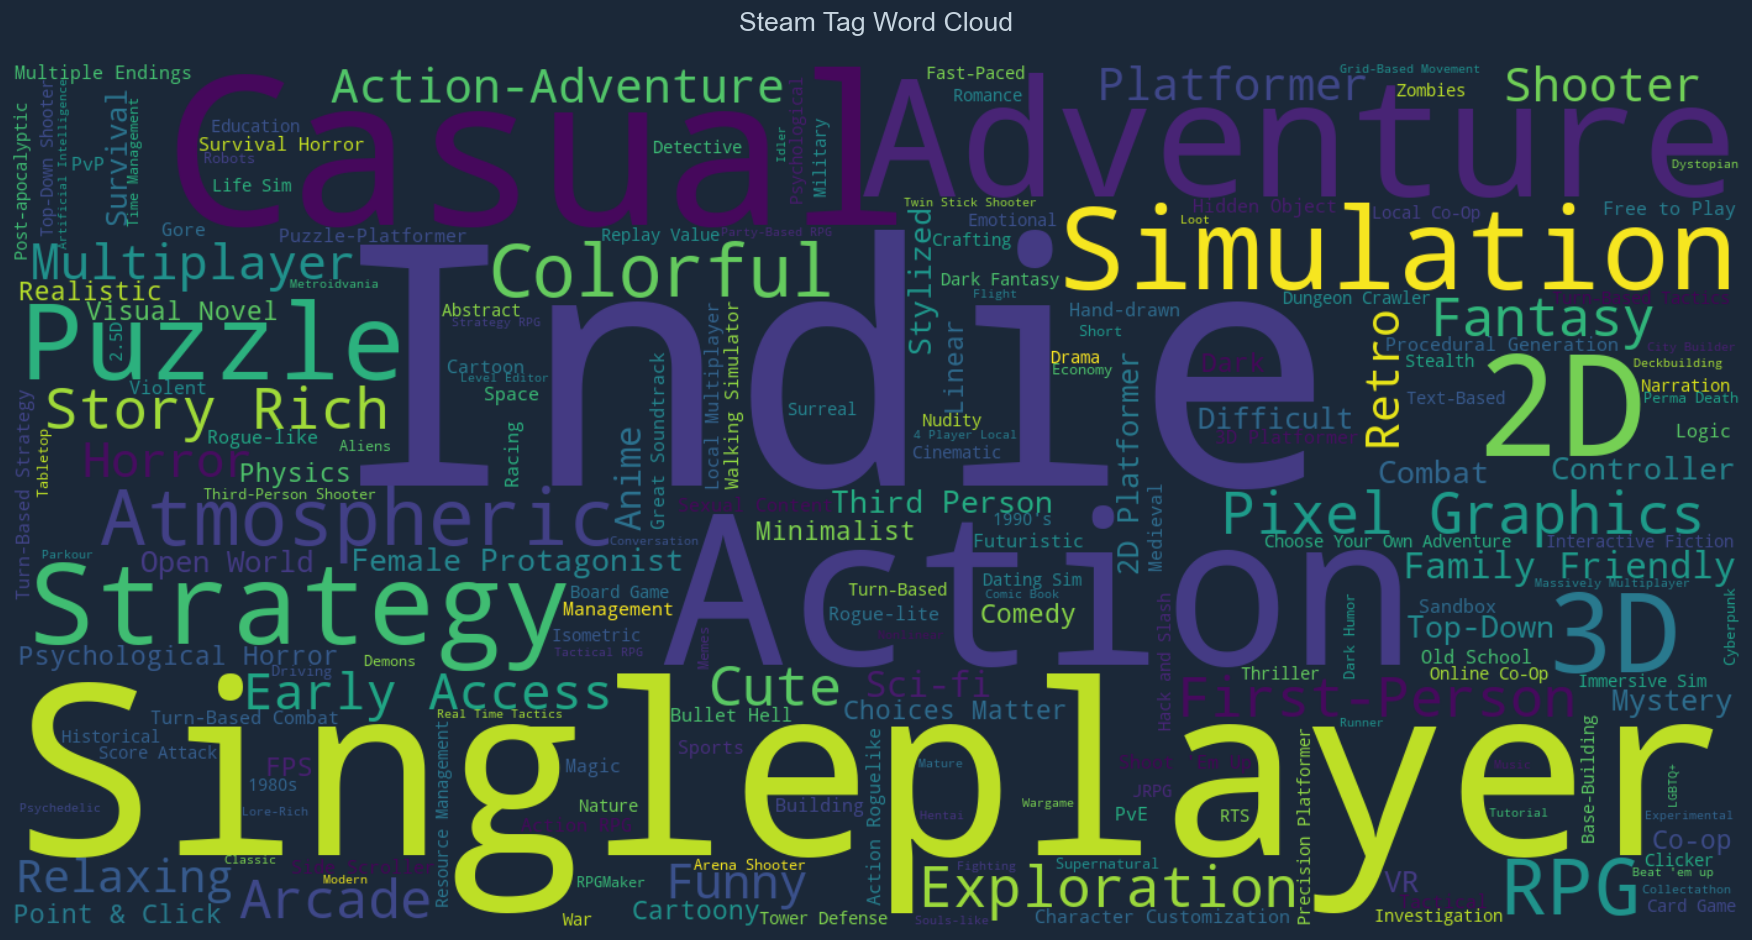

保存图表: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/figures/46_text_tag_wordcloud.png


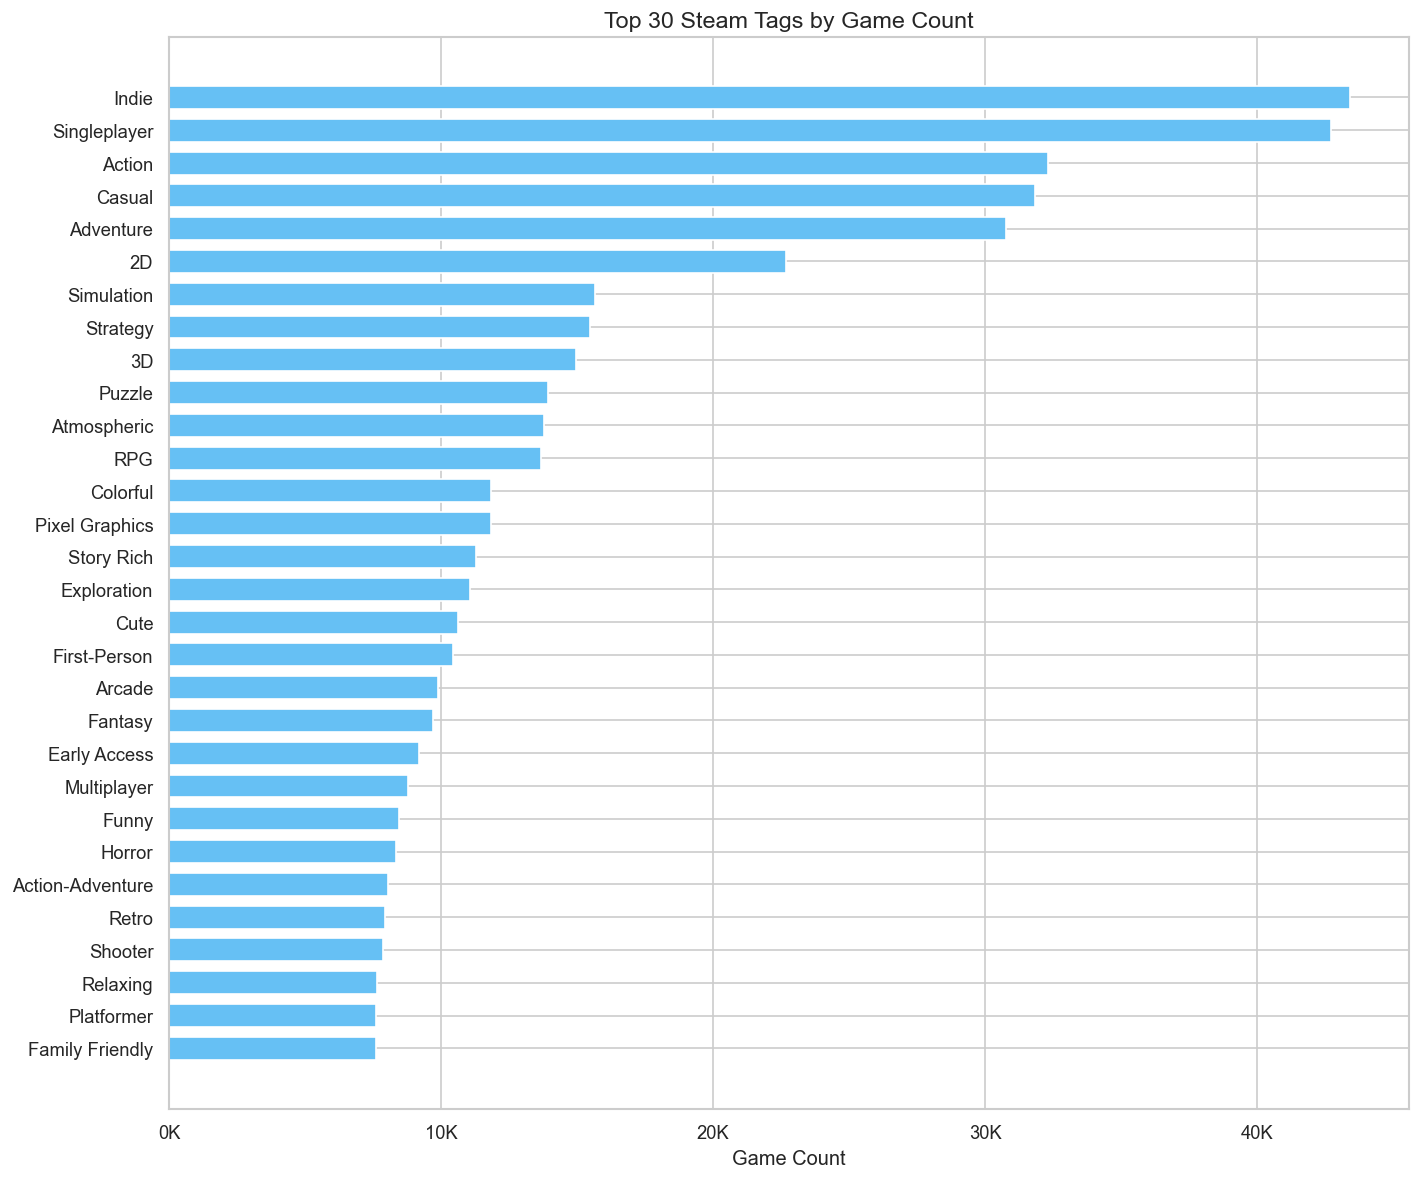

保存图表: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/figures/46b_text_top30_tags_bar.png


In [3]:
def parse_list_column(series):
    """Parse pipe-delimited string column into list of strings."""
    def _parse(val):
        if pd.isna(val) or not val:
            return []
        s = str(val).strip()
        if not s:
            return []
        sep = "|" if "|" in s else ";"
        return [t.strip() for t in s.split(sep) if t.strip()]
    return series.apply(_parse)

# Parse tags and count frequencies
tag_lists = parse_list_column(df["tags_list"])
all_tag_words = []
for lst in tag_lists:
    all_tag_words.extend(lst)

# Count frequency
from collections import Counter
tag_freq = Counter(all_tag_words)
print(f"唯一标签数: {len(tag_freq)}")
print(f"标签总出现次数: {sum(tag_freq.values()):,}")
print(f"\nTop 30 标签:")
for tag, count in tag_freq.most_common(30):
    print(f"  {tag}: {count:,} ({count / len(df) * 100:.1f}%)")

# Generate tag word cloud
tag_freq_dict = dict(tag_freq)
wordcloud = WordCloud(
    width=1400, height=700,
    background_color="#1b2838",
    colormap="viridis",
    max_words=200,
    collocations=False,
    stopwords=set(),
    relative_scaling=0.5,
).generate_from_frequencies(tag_freq_dict)

fig, ax = plt.subplots(figsize=(16, 8))
ax.imshow(wordcloud, interpolation="bilinear")
ax.axis("off")
ax.set_title("Steam Tag Word Cloud", fontsize=16, color="#c6d4df",
             backgroundcolor="#1b2838", pad=20)
fig.patch.set_facecolor("#1b2838")
plt.tight_layout()
fig_path = FIGURES_DIR / "46_text_tag_wordcloud.png"
plt.savefig(fig_path, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("保存图表:", fig_path)

# Also create a horizontal bar chart of top 30 tags
fig2, ax2 = plt.subplots(figsize=(12, 10))
top30 = tag_freq.most_common(30)
ax2.barh([t for t, _ in reversed(top30)], [c for _, c in reversed(top30)],
         color="#66c0f4", height=0.7)
ax2.set_xlabel("Game Count")
ax2.set_title("Top 30 Steam Tags by Game Count", fontsize=14)
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))
plt.tight_layout()
fig_path2 = FIGURES_DIR / "46b_text_top30_tags_bar.png"
plt.savefig(fig_path2, bbox_inches="tight")
plt.show()
print("保存图表:", fig_path2)

# Save tag frequency data
tag_freq_df = pd.DataFrame(tag_freq.most_common(100), columns=["tag", "game_count"])
tag_freq_df.to_csv(PROCESSED_DIR / "steam_text_tag_frequency.csv", index=False)


## 3. 描述文本词云 — 热度不同的游戏在说什么？

将游戏按评论数分为高评论组（≥100 条评论）和低评论组（<100 条评论），分别生成 `short_description` 词云，观察两组游戏在描述语言上的差异。

这有助于回答一个直观问题：**能获得更多玩家关注的游戏，在宣传描述中是否使用了不同的词汇？**

高评论组 (≥100): 20,162 游戏
低评论组 (<100): 69,456 游戏


高评论组词汇量: 379,883 words
低评论组词汇量: 1,174,345 words


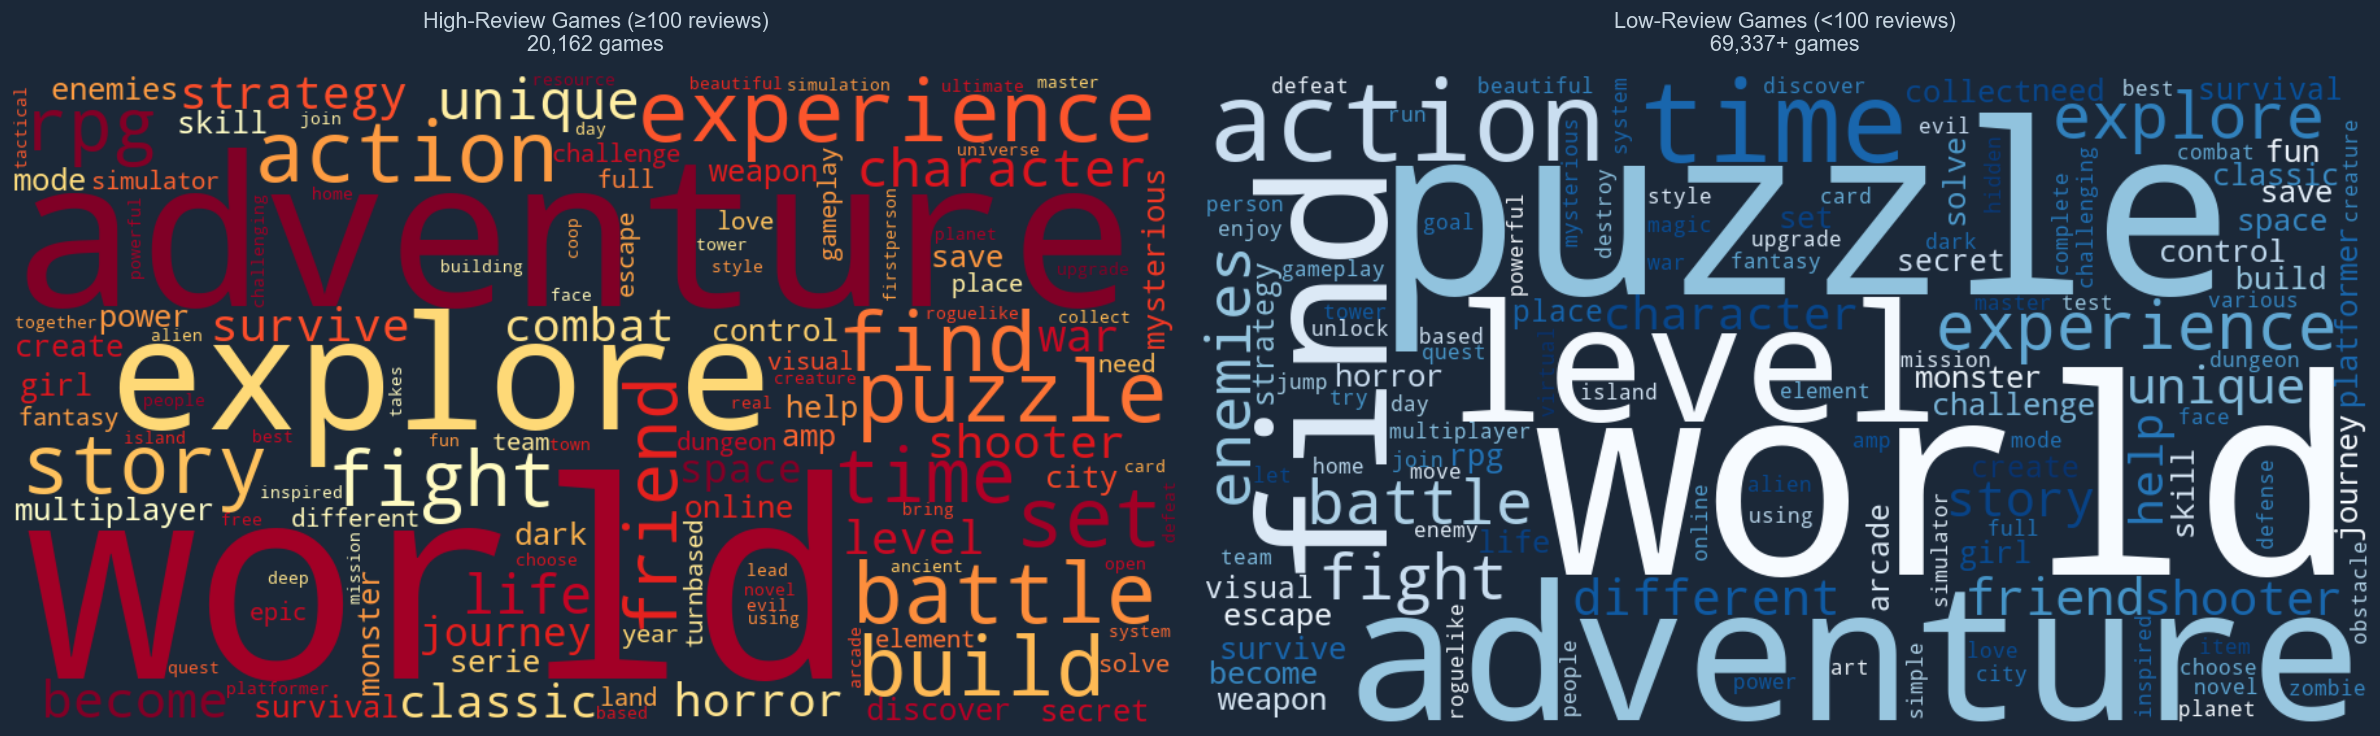

保存图表: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/figures/47_text_description_wordcloud_comparison.png

高评论组 Top 15 描述词:
  world: 4,147
  adventure: 2,140
  explore: 1,565
  experience: 1,528
  action: 1,459
  story: 1,372
  set: 1,310
  build: 1,304
  find: 1,295
  fight: 1,258
  time: 1,207
  rpg: 1,182
  unique: 1,156
  life: 1,089
  battle: 969

低评论组 Top 15 描述词:
  world: 10,231
  adventure: 6,184
  find: 5,507
  puzzle: 5,274
  time: 4,406
  explore: 4,314
  action: 4,310
  experience: 4,279
  enemies: 4,119
  fight: 3,955
  unique: 3,790
  story: 3,575
  different: 3,495
  levels: 3,425
  puzzles: 3,219


In [4]:
def clean_text_for_wordcloud(series, min_word_len=3):
    """Clean a series of text strings for word cloud generation."""
    all_text = []
    for val in series.dropna():
        text = str(val).lower()
        # Remove non-alpha characters (keep spaces)
        words = []
        for word in text.split():
            # Remove punctuation and filter
            cleaned = "".join(c for c in word if c.isalpha())
            if len(cleaned) >= min_word_len and cleaned not in ALL_STOPWORDS:
                words.append(cleaned)
        all_text.extend(words)
    return " ".join(all_text)

# Split into high and low review groups
high_review_mask = df["review_count_calc"] >= 100
desc_high = df.loc[high_review_mask, "short_description"]
desc_low = df.loc[~high_review_mask, "short_description"]

print(f"高评论组 (≥100): {len(desc_high):,} 游戏")
print(f"低评论组 (<100): {len(desc_low):,} 游戏")

text_high = clean_text_for_wordcloud(desc_high)
text_low = clean_text_for_wordcloud(desc_low)
print(f"高评论组词汇量: {len(text_high.split()):,} words")
print(f"低评论组词汇量: {len(text_low.split()):,} words")

# Generate word clouds side by side
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for ax, text, title, cmap in [
    (axes[0], text_high, f"High-Review Games (≥100 reviews)\n{n_high:,} games", "YlOrRd"),
    (axes[1], text_low, f"Low-Review Games (<100 reviews)\n{n_low:,}+ games", "Blues"),
]:
    if text.strip():
        wc = WordCloud(
            width=900, height=500,
            background_color="#1b2838",
            colormap=cmap,
            max_words=120,
            collocations=False,
            stopwords=set(),
        ).generate(text)
        ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(title, fontsize=13, color="#c6d4df", backgroundcolor="#1b2838", pad=15)

fig.patch.set_facecolor("#1b2838")
plt.tight_layout()
fig_path = FIGURES_DIR / "47_text_description_wordcloud_comparison.png"
plt.savefig(fig_path, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("保存图表:", fig_path)

# Compute top words difference for each group
def get_top_words(text, n=30):
    words = [w for w in text.split() if len(w) >= 3]
    return Counter(words).most_common(n)

top_high = dict(get_top_words(text_high, 40))
top_low = dict(get_top_words(text_low, 40))

print("\n高评论组 Top 15 描述词:")
for word, count in list(top_high.items())[:15]:
    print(f"  {word}: {count:,}")
print("\n低评论组 Top 15 描述词:")
for word, count in list(top_low.items())[:15]:
    print(f"  {word}: {count:,}")


## 4. TF-IDF 关键词对比 — 什么词能区分高热度游戏？

TF-IDF（词频-逆文档频率）能识别出那些在某一类游戏中频繁出现、但在另一类中较少出现的"区分性关键词"。本节将高评论（≥100 条）和低评论（<100 条）描述文本分别作为两个"语料组"，提取各自最具区分性的关键词。

需要注意的是，这只是描述性的文本对比，不能解释为"使用某些词就能获得更多评论"。

TF-IDF 语料: 80,640 文档 (HIGH: 20,160, LOW: 60,480)



=== 高评论组区分性关键词 (High - Low TF-IDF) ===
  world                           high=0.0421  low=0.0308  diff=0.0113
  series                          high=0.0124  low=0.0052  diff=0.0072
  build                           high=0.0171  low=0.0104  diff=0.0067
  set                             high=0.0179  low=0.0115  diff=0.0064
  online                          high=0.0119  low=0.0062  diff=0.0058
  war                             high=0.0118  low=0.0064  diff=0.0053
  tactical                        high=0.0080  low=0.0032  diff=0.0048
  coop                            high=0.0083  low=0.0036  diff=0.0047
  story                           high=0.0191  low=0.0145  diff=0.0046
  life                            high=0.0161  low=0.0115  diff=0.0046
  rpg                             high=0.0158  low=0.0113  diff=0.0045
  epic                            high=0.0093  low=0.0048  diff=0.0045
  combat                          high=0.0123  low=0.0080  diff=0.0043
  strategy                        hig

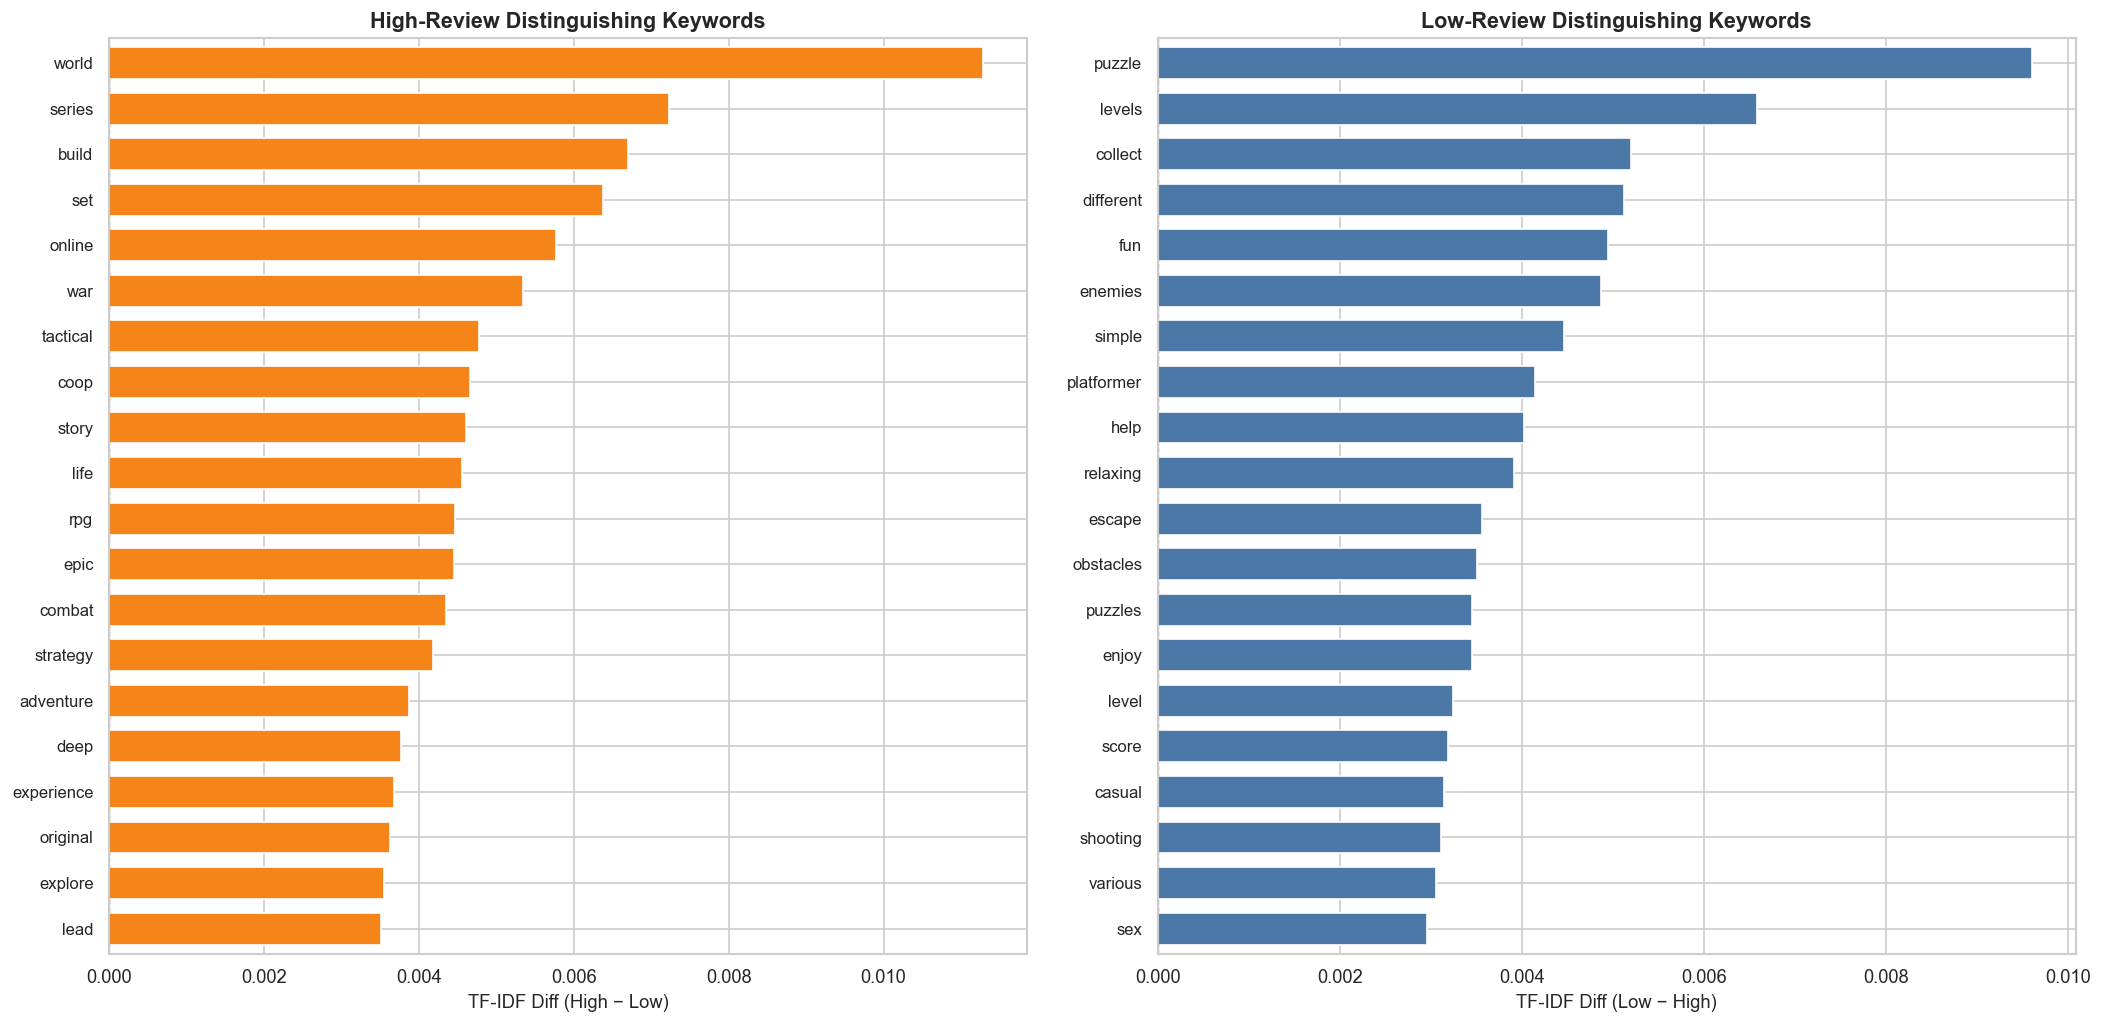


保存图表: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/figures/48_text_tfidf_high_vs_low_keywords.png


In [5]:
def prepare_tfidf_text(series, min_word_len=3):
    """Prepare text for TF-IDF by cleaning and joining."""
    texts = []
    for val in series.dropna():
        text = str(val).lower()
        words = []
        for word in text.split():
            cleaned = "".join(c for c in word if c.isalpha())
            if len(cleaned) >= min_word_len and cleaned not in ALL_STOPWORDS:
                words.append(cleaned)
        if words:
            texts.append(" ".join(words))
    return texts

# Prepare texts
texts_high = prepare_tfidf_text(desc_high)
texts_low = prepare_tfidf_text(desc_low)

# Sample low-review texts to match size for comparison
if len(texts_low) > len(texts_high) * 3:
    np.random.seed(42)
    texts_low_sample = list(np.random.choice(texts_low, size=len(texts_high) * 3, replace=False))
else:
    texts_low_sample = texts_low

all_texts = texts_high + texts_low_sample
labels = ["HIGH_REVIEW"] * len(texts_high) + ["LOW_REVIEW"] * len(texts_low_sample)
print(f"TF-IDF 语料: {len(all_texts):,} 文档 (HIGH: {len(texts_high):,}, LOW: {len(texts_low_sample):,})")

# TF-IDF Vectorizer
vectorizer = TfidfVectorizer(
    max_features=500,
    min_df=5,
    max_df=0.85,
    ngram_range=(1, 2),
    stop_words="english",
)

tfidf_matrix = vectorizer.fit_transform(all_texts)
feature_names = vectorizer.get_feature_names_out()

# Average TF-IDF per group
high_indices = [i for i, l in enumerate(labels) if l == "HIGH_REVIEW"]
low_indices = [i for i, l in enumerate(labels) if l == "LOW_REVIEW"]

high_tfidf_mean = np.array(tfidf_matrix[high_indices].mean(axis=0)).flatten()
low_tfidf_mean = np.array(tfidf_matrix[low_indices].mean(axis=0)).flatten()

# Find distinguishing words: biggest difference in mean TF-IDF
tfidf_diff = pd.DataFrame({
    "word": feature_names,
    "high_tfidf": high_tfidf_mean,
    "low_tfidf": low_tfidf_mean,
    "diff_high_minus_low": high_tfidf_mean - low_tfidf_mean,
})

top_high_words = tfidf_diff.nlargest(25, "diff_high_minus_low")
top_low_words = tfidf_diff.nsmallest(25, "diff_high_minus_low")

print("\n=== 高评论组区分性关键词 (High - Low TF-IDF) ===")
for _, row in top_high_words.head(20).iterrows():
    print(f"  {row['word']:<30s}  high={row['high_tfidf']:.4f}  low={row['low_tfidf']:.4f}  diff={row['diff_high_minus_low']:.4f}")

print("\n=== 低评论组区分性关键词 (Low - High TF-IDF) ===")
for _, row in top_low_words.head(20).iterrows():
    print(f"  {row['word']:<30s}  high={row['high_tfidf']:.4f}  low={row['low_tfidf']:.4f}  diff={row['diff_high_minus_low']:.4f}")

# Visualization — wider layout with more space for y-axis labels
fig, axes = plt.subplots(1, 2, figsize=(18, 9))

# High-review distinguishing words
plot_high = top_high_words.head(20).iloc[::-1]
axes[0].barh(range(len(plot_high)), plot_high["diff_high_minus_low"], color="#F58518", height=0.7)
axes[0].set_yticks(range(len(plot_high)))
axes[0].set_yticklabels(plot_high["word"], fontsize=10)
axes[0].set_title("High-Review Distinguishing Keywords", fontsize=13, fontweight="bold")
axes[0].set_xlabel("TF-IDF Diff (High − Low)", fontsize=11)
axes[0].axvline(x=0, color="gray", linestyle="--", linewidth=0.8)
axes[0].margins(y=0.01)

# Low-review distinguishing words
plot_low = top_low_words.head(20).iloc[::-1]
axes[1].barh(range(len(plot_low)), -plot_low["diff_high_minus_low"], color="#4C78A8", height=0.7)
axes[1].set_yticks(range(len(plot_low)))
axes[1].set_yticklabels(plot_low["word"], fontsize=10)
axes[1].set_title("Low-Review Distinguishing Keywords", fontsize=13, fontweight="bold")
axes[1].set_xlabel("TF-IDF Diff (Low − High)", fontsize=11)
axes[1].axvline(x=0, color="gray", linestyle="--", linewidth=0.8)
axes[1].margins(y=0.01)

# Ensure y-axis labels are fully visible
fig.subplots_adjust(left=0.08, right=0.95, wspace=0.35, bottom=0.08, top=0.93)
plt.tight_layout(pad=2.0)
fig_path = FIGURES_DIR / "48_text_tfidf_high_vs_low_keywords.png"
plt.savefig(fig_path, bbox_inches="tight", dpi=160)
plt.show()
print("\n保存图表:", fig_path)

# Save TF-IDF results
tfidf_diff.to_csv(PROCESSED_DIR / "steam_text_tfidf_keywords.csv", index=False)


## 5. 文本长度与玩家关注度的关系

在 Notebook 03 中已经生成了 `short_description_length` 和 `about_the_game_length` 特征。本节进一步将这些特征与评论数量、好评率进行可视化对比，观察是否存在"描述越长、越详细的游戏更容易获得玩家关注"的现象。

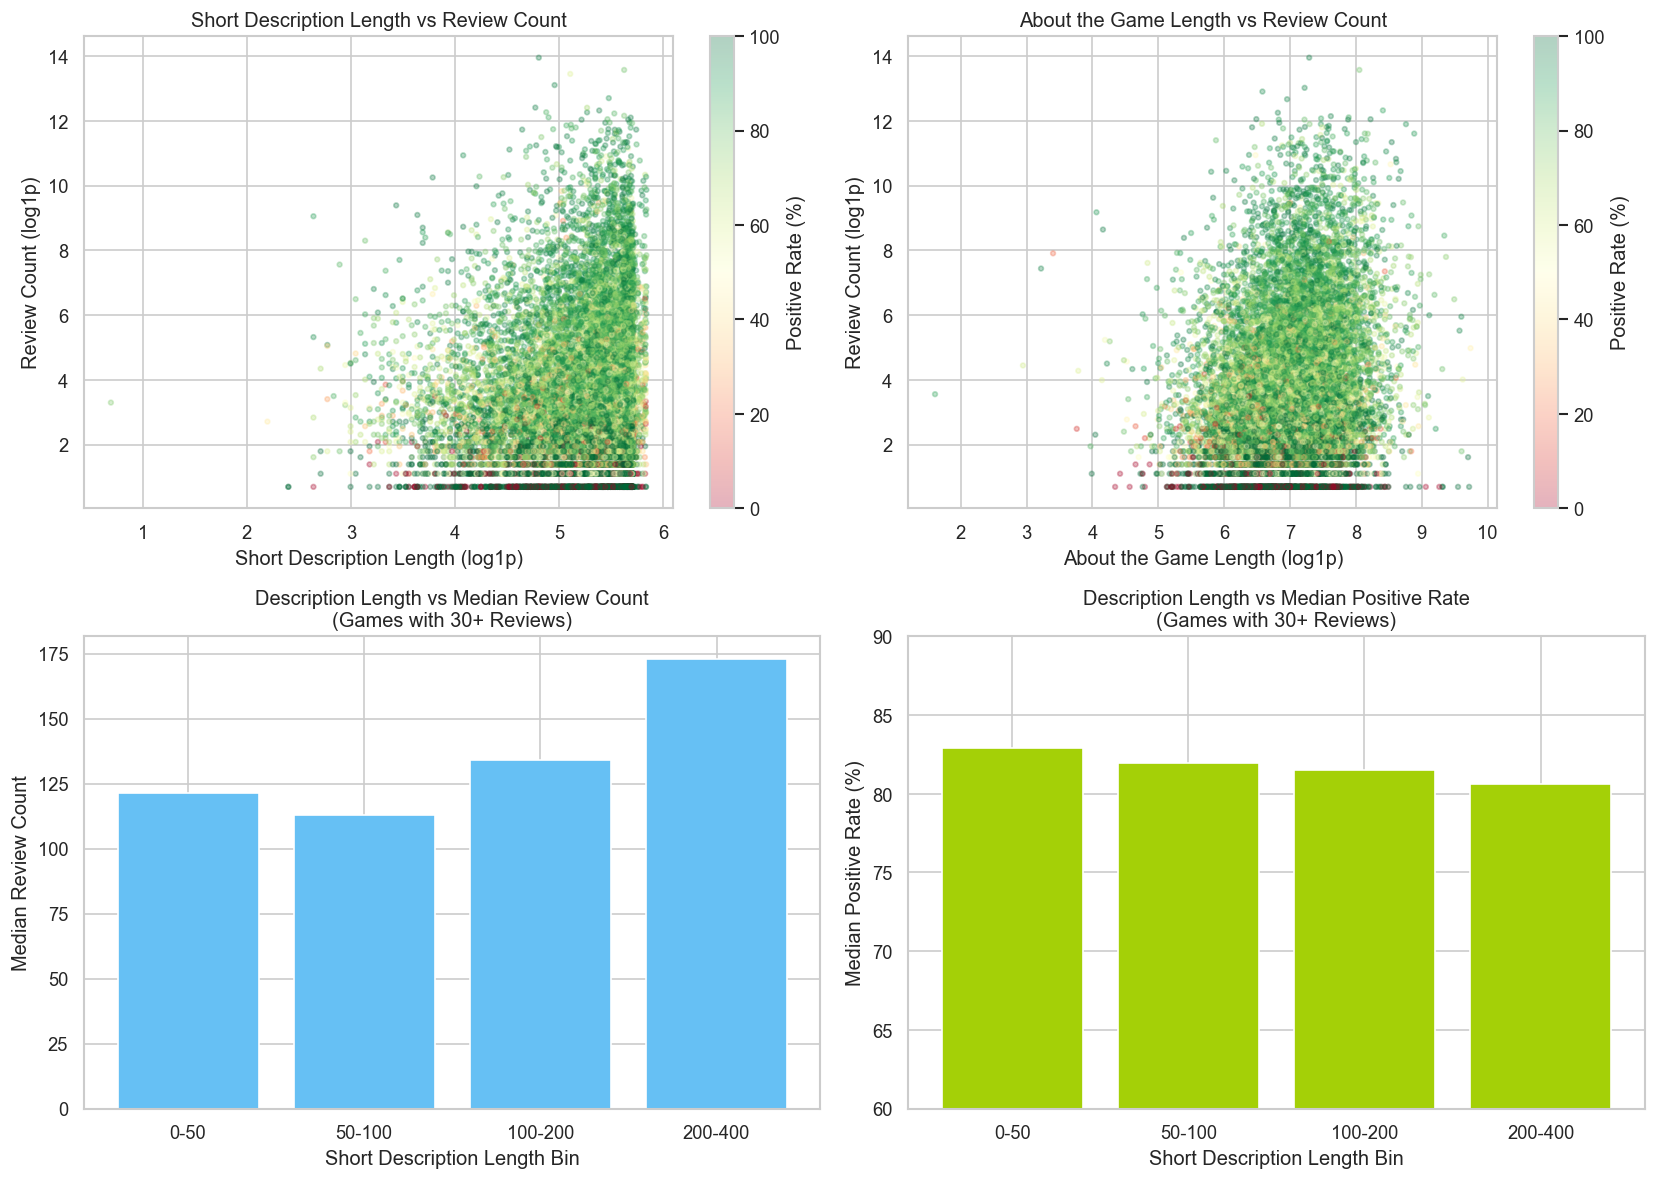

保存图表: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/figures/49_text_length_vs_popularity.png

描述长度与玩家关注度 (30+ 评论游戏):


,desc_len_bin,game_count,median_review_count,median_positive_rate
0,0-50,832,121.5,82.912557
1,50-100,2853,113.0,81.951220
2,100-200,10382,134.0,81.536276
3,200-400,19288,173.0,80.642280



相关系数:


,short_description_length,about_the_game_length,review_count_calc,positive_rate_calc
short_description_length,1.000,0.241,0.008,-0.019
about_the_game_length,0.241,1.000,0.022,0.013
review_count_calc,0.008,0.022,1.000,0.033
positive_rate_calc,-0.019,0.013,0.033,1.000


In [6]:
# Text length vs review count
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Short description length vs review count
sample_df = df[df["short_description_length"] > 0].sample(min(20000, len(df)), random_state=42)
sc1 = axes[0, 0].scatter(
    np.log1p(sample_df["short_description_length"]),
    np.log1p(sample_df["review_count_calc"].clip(lower=0)),
    c=sample_df["positive_rate_calc"],
    cmap="RdYlGn", alpha=0.3, s=8
)
axes[0, 0].set_xlabel("Short Description Length (log1p)")
axes[0, 0].set_ylabel("Review Count (log1p)")
axes[0, 0].set_title("Short Description Length vs Review Count")
plt.colorbar(sc1, ax=axes[0, 0], label="Positive Rate (%)")

# About the game length vs review count
sample_df2 = df[df["about_the_game_length"] > 0].sample(min(20000, len(df)), random_state=42)
sc2 = axes[0, 1].scatter(
    np.log1p(sample_df2["about_the_game_length"]),
    np.log1p(sample_df2["review_count_calc"].clip(lower=0)),
    c=sample_df2["positive_rate_calc"],
    cmap="RdYlGn", alpha=0.3, s=8
)
axes[0, 1].set_xlabel("About the Game Length (log1p)")
axes[0, 1].set_ylabel("Review Count (log1p)")
axes[0, 1].set_title("About the Game Length vs Review Count")
plt.colorbar(sc2, ax=axes[0, 1], label="Positive Rate (%)")

# Short description length vs positive rate (reliable reviews)
reliable = df[df["has_reliable_reviews"] & (df["short_description_length"] > 0)]
# Bin by short description length
reliable["desc_len_bin"] = pd.cut(
    reliable["short_description_length"],
    bins=[0, 50, 100, 200, 400, 800, 1600, 100000],
    labels=["0-50", "50-100", "100-200", "200-400", "400-800", "800-1600", "1600+"]
)
len_bin_stats = reliable.groupby("desc_len_bin", observed=True).agg(
    game_count=("appid", "count"),
    median_review_count=("review_count_calc", "median"),
    median_positive_rate=("positive_rate_calc", "median"),
).reset_index()

axes[1, 0].bar(len_bin_stats["desc_len_bin"], len_bin_stats["median_review_count"],
               color="#66c0f4", edgecolor="white")
axes[1, 0].set_xlabel("Short Description Length Bin")
axes[1, 0].set_ylabel("Median Review Count")
axes[1, 0].set_title("Description Length vs Median Review Count\n(Games with 30+ Reviews)")

axes[1, 1].bar(len_bin_stats["desc_len_bin"], len_bin_stats["median_positive_rate"],
               color="#a4d007", edgecolor="white")
axes[1, 1].set_xlabel("Short Description Length Bin")
axes[1, 1].set_ylabel("Median Positive Rate (%)")
axes[1, 1].set_title("Description Length vs Median Positive Rate\n(Games with 30+ Reviews)")
axes[1, 1].set_ylim(60, 90)

plt.tight_layout()
fig_path = FIGURES_DIR / "49_text_length_vs_popularity.png"
plt.savefig(fig_path, bbox_inches="tight")
plt.show()
print("保存图表:", fig_path)

# Print summary stats
print("\n描述长度与玩家关注度 (30+ 评论游戏):")
display(len_bin_stats)

# Correlation
corr_len_review = reliable[["short_description_length", "about_the_game_length",
                            "review_count_calc", "positive_rate_calc"]].corr().round(3)
print("\n相关系数:")
display(corr_len_review)

len_bin_stats.to_csv(PROCESSED_DIR / "steam_text_length_vs_popularity.csv", index=False)


## 6. 标签丰富度与市场表现

在 Notebook 06 中已经分析了标签频率和共现关系。本节从"标签丰富度"角度补充分析：**标签数量更多的游戏是否更容易获得玩家关注？** 这里关注的是标签的"颗粒度"——Steam 标签越细致，游戏的市场定位越清晰，这可能是文本信息量与市场表现的关联点。

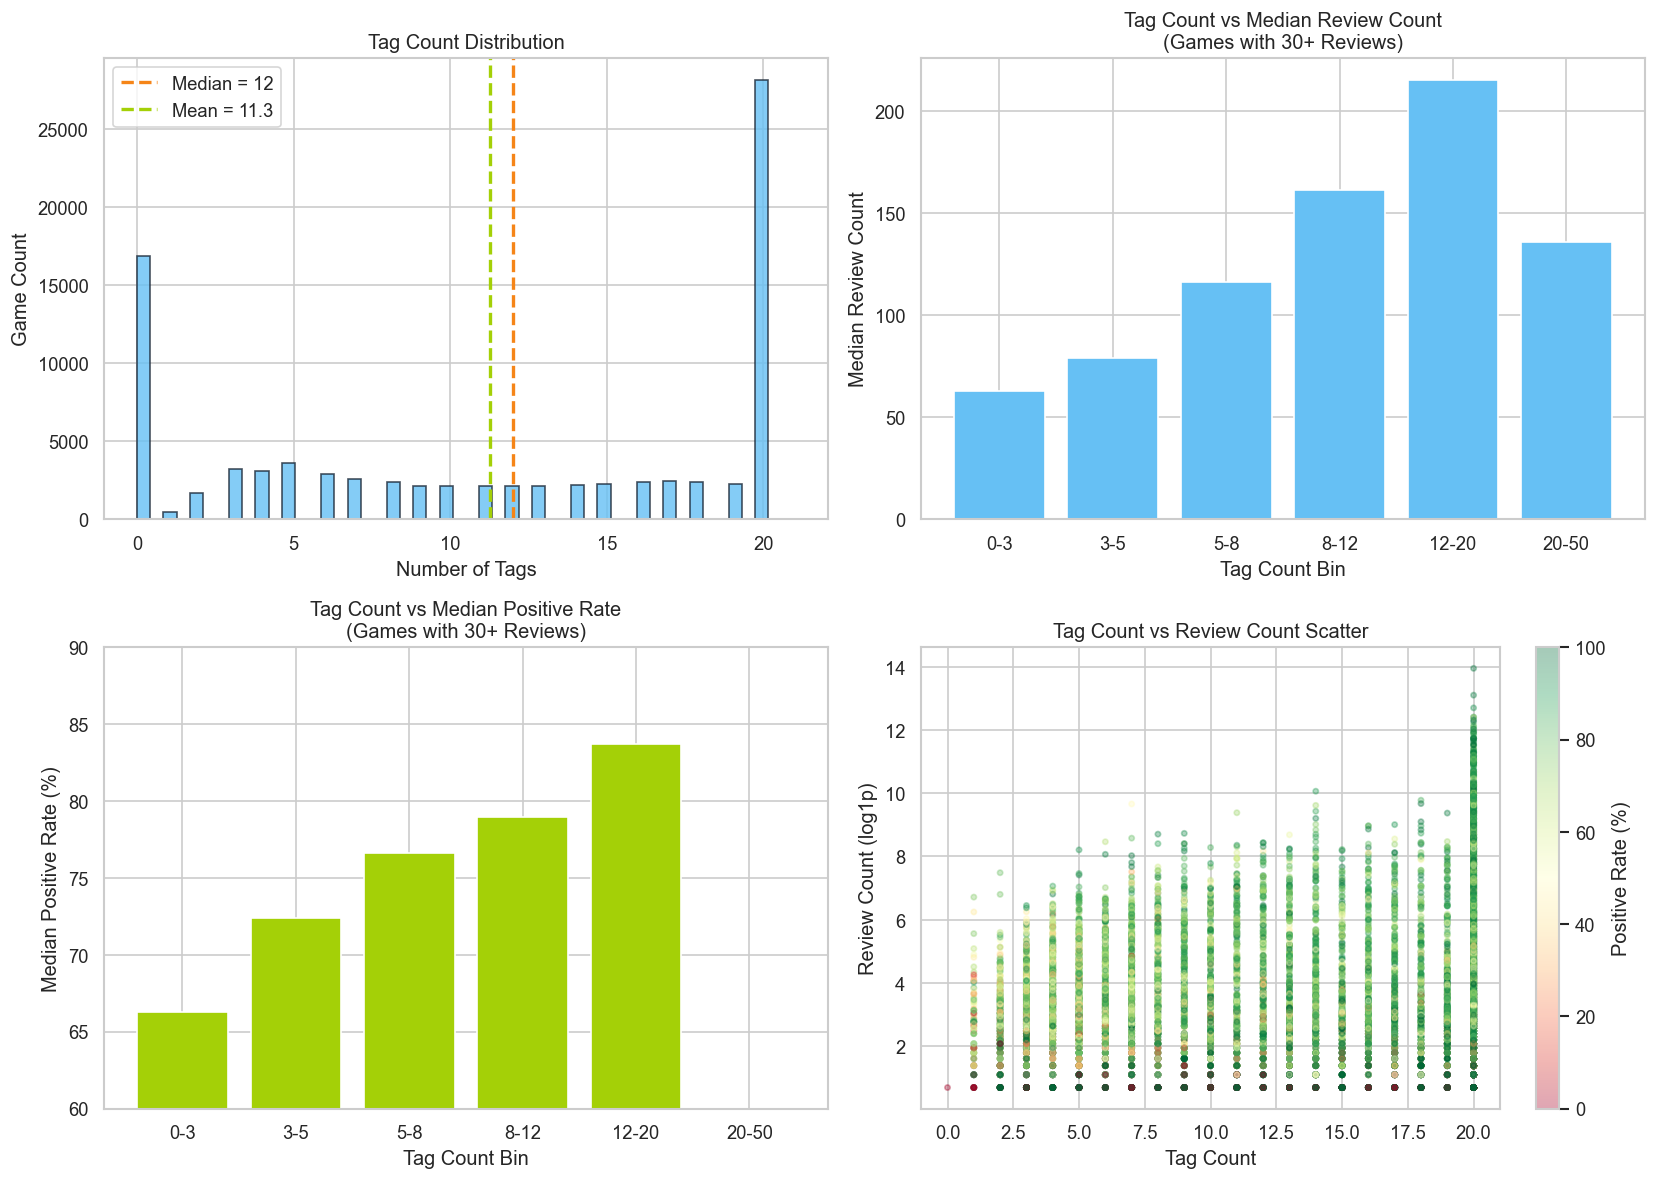

保存图表: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/figures/50_text_tag_richness_vs_popularity.png

标签数量与玩家关注度:


,tag_count_bin,game_count,median_review_count,median_positive_rate
0,0-3,1571,63.0,66.304348
1,3-5,2829,79.0,72.368421
2,5-8,3675,116.0,76.615385
3,8-12,3604,161.0,78.961801
4,12-20,21677,215.0,83.695652
5,20-50,1,136.0,51.470588



标签数量与评论数/好评率的相关系数:


,tags_count,genres_count,categories_count,review_count_calc,positive_rate_calc
tags_count,1.000,0.172,0.204,0.052,0.275
genres_count,0.172,1.000,0.046,-0.007,-0.098
categories_count,0.204,0.046,1.000,0.088,0.080
review_count_calc,0.052,-0.007,0.088,1.000,0.033
positive_rate_calc,0.275,-0.098,0.080,0.033,1.000


In [7]:
# Tag count distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distribution of tag counts
axes[0, 0].hist(df["tags_count"], bins=50, color="#66c0f4", edgecolor="#1b2838", alpha=0.8)
axes[0, 0].axvline(df["tags_count"].median(), color="#F58518", linestyle="--", linewidth=2,
                   label=f'Median = {df["tags_count"].median():.0f}')
axes[0, 0].axvline(df["tags_count"].mean(), color="#a4d007", linestyle="--", linewidth=2,
                   label=f'Mean = {df["tags_count"].mean():.1f}')
axes[0, 0].set_xlabel("Number of Tags")
axes[0, 0].set_ylabel("Game Count")
axes[0, 0].set_title("Tag Count Distribution")
axes[0, 0].legend()

# Tag count vs review count (reliable reviews)
reliable_df = df[df["has_reliable_reviews"]].copy()
reliable_df["tag_count_bin"] = pd.cut(
    reliable_df["tags_count"],
    bins=[0, 3, 5, 8, 12, 20, 50, 500],
    labels=["0-3", "3-5", "5-8", "8-12", "12-20", "20-50", "50+"]
)
tag_bin_stats = reliable_df.groupby("tag_count_bin", observed=True).agg(
    game_count=("appid", "count"),
    median_review_count=("review_count_calc", "median"),
    median_positive_rate=("positive_rate_calc", "median"),
).reset_index()

axes[0, 1].bar(tag_bin_stats["tag_count_bin"], tag_bin_stats["median_review_count"],
               color="#66c0f4", edgecolor="white")
axes[0, 1].set_xlabel("Tag Count Bin")
axes[0, 1].set_ylabel("Median Review Count")
axes[0, 1].set_title("Tag Count vs Median Review Count\n(Games with 30+ Reviews)")

axes[1, 0].bar(tag_bin_stats["tag_count_bin"], tag_bin_stats["median_positive_rate"],
               color="#a4d007", edgecolor="white")
axes[1, 0].set_xlabel("Tag Count Bin")
axes[1, 0].set_ylabel("Median Positive Rate (%)")
axes[1, 0].set_title("Tag Count vs Median Positive Rate\n(Games with 30+ Reviews)")
axes[1, 0].set_ylim(60, 90)

# Tag count vs review count scatter (log scale)
sample = df.sample(min(15000, len(df)), random_state=42)
sc = axes[1, 1].scatter(
    sample["tags_count"],
    np.log1p(sample["review_count_calc"].clip(lower=0)),
    c=sample["positive_rate_calc"],
    cmap="RdYlGn", alpha=0.35, s=10
)
axes[1, 1].set_xlabel("Tag Count")
axes[1, 1].set_ylabel("Review Count (log1p)")
axes[1, 1].set_title("Tag Count vs Review Count Scatter")
plt.colorbar(sc, ax=axes[1, 1], label="Positive Rate (%)")

plt.tight_layout()
fig_path = FIGURES_DIR / "50_text_tag_richness_vs_popularity.png"
plt.savefig(fig_path, bbox_inches="tight")
plt.show()
print("保存图表:", fig_path)

print("\n标签数量与玩家关注度:")
display(tag_bin_stats)

# Correlation
print("\n标签数量与评论数/好评率的相关系数:")
corr_tags = reliable_df[["tags_count", "genres_count", "categories_count",
                          "review_count_calc", "positive_rate_calc"]].corr().round(3)
display(corr_tags)

tag_bin_stats.to_csv(PROCESSED_DIR / "steam_text_tag_richness_vs_popularity.csv", index=False)


## 7. 图数据视角 — 从标签共现到异构图建模

课程将**图数据**列为六大数据类型之一。在前面的分析和 steam-scope 网页展示中，已经将游戏、标签、类型和分类抽象为**异构图（Heterogeneous Graph）**结构：

```
Game ──has_tag──→ Tag
Game ──has_genre──→ Genre
Game ──has_category──→ Category
```

在这个图中：
- **节点类型**包括 Game（89,618 个）、Tag（452 个）、Genre（33 个）、Category（40 个），总计约 90,143 个节点
- **边**代表"游戏使用了某个标签/类型/分类"，总计约 1,643,164 条边
- **标签共现**可以通过 Jaccard 相似度计算，反映两个标签在同一款游戏中共同出现的频率

这种图表示方法的优势在于：
1. 将表格数据中的多标签字段转化为**实体关系**，方便进行图算法分析
2. 标签共现网络可以揭示市场中的标签组合模式（如 Indie + Singleplayer）
3. 基于图相似度的游戏推荐（Jaccard 相似度）已经在 steam-scope 的推荐页中实现

下面展示标签共现网络的统计摘要，该网络的完整可视化已在 steam-scope 网页中实现。

In [8]:
# Compute graph statistics summary
tags_parsed = parse_list_column(df["tags_list"])
genres_parsed = parse_list_column(df["genres_list"])
categories_parsed = parse_list_column(df["categories_list"])

all_tags_set = set()
all_genres_set = set()
all_categories_set = set()
game_tag_edges = 0
game_genre_edges = 0
game_category_edges = 0

for i in range(len(df)):
    tags = tags_parsed.iloc[i]
    genres = genres_parsed.iloc[i]
    cats = categories_parsed.iloc[i]
    all_tags_set.update(tags)
    all_genres_set.update(genres)
    all_categories_set.update(cats)
    game_tag_edges += len(tags)
    game_genre_edges += len(genres)
    game_category_edges += len(cats)

total_edges = game_tag_edges + game_genre_edges + game_category_edges
total_nodes = len(df) + len(all_tags_set) + len(all_genres_set) + len(all_categories_set)

graph_summary = pd.DataFrame({
    "节点类型": ["Game", "Tag", "Genre", "Category", "总计"],
    "节点数": [
        f"{len(df):,}",
        f"{len(all_tags_set):,}",
        f"{len(all_genres_set):,}",
        f"{len(all_categories_set):,}",
        f"{total_nodes:,}",
    ],
    "边关系": [
        "—",
        f"Game→Tag: {game_tag_edges:,}",
        f"Game→Genre: {game_genre_edges:,}",
        f"Game→Category: {game_category_edges:,}",
        f"总边数: {total_edges:,}",
    ],
})

print("Steam 游戏异构图结构统计:")
display(graph_summary)

graph_summary.to_csv(PROCESSED_DIR / "steam_text_graph_summary.csv", index=False, encoding="utf-8-sig")

# Top co-occurring tag pairs (Jaccard)
from itertools import combinations

top_tags = [t for t, _ in Counter(t for lst in tags_parsed for t in lst).most_common(30)]
top_tag_set = set(top_tags)

cooccur = Counter()
tag_game_counts = Counter()
for lst in tags_parsed:
    filtered = [t for t in lst if t in top_tag_set]
    for t in filtered:
        tag_game_counts[t] += 1
    for a, b in combinations(sorted(filtered), 2):
        cooccur[(a, b)] += 1

print(f"\nTop 15 标签共现对 (基于 Top 30 标签):")
for (a, b), count in cooccur.most_common(15):
    jac = count / (tag_game_counts[a] + tag_game_counts[b] - count)
    print(f"  {a:<25s} + {b:<25s}  共现={count:>6,}  Jaccard={jac:.3f}")


Steam 游戏异构图结构统计:


,节点类型,节点数,边关系
0,Game,"89,618",—
1,Tag,452,"Game→Tag: 1,008,987"
2,Genre,33,"Game→Genre: 258,024"
3,Category,40,"Game→Category: 376,153"
4,总计,"90,143","总边数: 1,643,164"



Top 15 标签共现对 (基于 Top 30 标签):
  Indie                     + Singleplayer               共现=26,699  Jaccard=0.449
  Casual                    + Indie                      共现=20,948  Jaccard=0.386
  Action                    + Indie                      共现=20,027  Jaccard=0.360
  Casual                    + Singleplayer               共现=19,501  Jaccard=0.354
  Adventure                 + Singleplayer               共现=19,386  Jaccard=0.358
  Adventure                 + Indie                      共现=19,057  Jaccard=0.346
  Action                    + Singleplayer               共现=18,486  Jaccard=0.327
  2D                        + Singleplayer               共现=17,542  Jaccard=0.366
  Action                    + Adventure                  共现=14,581  Jaccard=0.301
  2D                        + Indie                      共现=13,710  Jaccard=0.262
  Adventure                 + Casual                     共现=11,888  Jaccard=0.234
  2D                        + Casual                     共现=11,441  